# Inspect `spy_ohlcv_1h.parquet`

Built by `ingest_spy_ohlcv.py` from the raw year-chunk JSON files in `steven/data/spy/spy_2010.json ... spy_2025.json`. Columns: `datetime`, `open`, `high`, `low`, `close`, `volume`. Hourly bars, regular market hours (09:30-16:00 ET), 2010-01-04 to 2025-05-30.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

DATA_PATH = Path("data") / "spy_ohlcv_1h.parquet"
df = pd.read_parquet(DATA_PATH)
print(df.shape)
print(f"date range: {df.datetime.min()} to {df.datetime.max()}")
display(df.head())
display(df.tail())

(27007, 6)
date range: 2010-01-04 09:30:00 to 2025-05-30 15:30:00


,datetime,open,high,low,close,volume
0,2010-01-04 09:30:00,112.3700,113.10,112.33,113.0850,35582306
1,2010-01-04 10:30:00,113.0800,113.29,113.06,113.2300,14305421
2,2010-01-04 11:30:00,113.2201,113.39,113.20,113.3000,10085735
3,2010-01-04 12:30:00,113.3000,113.38,113.27,113.3660,8362160
4,2010-01-04 13:30:00,113.3700,113.38,113.17,113.2125,8753512


,datetime,open,high,low,close,volume
27002,2025-05-30 11:30:00,589.11,589.36,584.68,585.09,9174432
27003,2025-05-30 12:30:00,585.07,586.06,583.25,585.89,13762180
27004,2025-05-30 13:30:00,585.89,588.72,585.54,588.29,9393426
27005,2025-05-30 14:30:00,588.28,590.93,587.76,590.62,8100110
27006,2025-05-30 15:30:00,590.64,591.12,589.24,589.46,20325887


## Shape, dtypes, basic stats

In [3]:
df.dtypes

datetime    datetime64[us]
open               float64
high               float64
low                float64
close              float64
volume               int64
dtype: object

In [4]:
df.describe()

,datetime,open,high,low,close,volume
count,27007,27007.000000,27007.000000,27007.000000,27007.000000,2.700700e+04
mean,2017-09-14 20:47:56.387603,280.469306,281.038467,279.868845,280.476337,1.350613e+07
min,2010-01-04 09:30:00,101.801700,102.210000,101.130000,101.801700,2.052600e+04
25%,2013-11-06 14:00:00,176.442500,176.660000,176.144950,176.449500,6.806613e+06
50%,2017-09-14 10:30:00,247.240000,247.520000,246.820000,247.230000,1.048045e+07
75%,2021-07-23 00:30:00,391.295000,392.410000,390.285000,391.400000,1.653229e+07
max,2025-05-30 15:30:00,612.820000,613.230000,612.080000,612.900000,1.897525e+08
std,NaN,133.482510,133.751036,133.196373,133.484404,1.064268e+07


In [5]:
print("date range:", df['datetime'].min(), "to", df['datetime'].max())
print("NaNs per column:")
df.isna().sum()

date range: 2010-01-04 09:30:00 to 2025-05-30 15:30:00
NaNs per column:


datetime    0
open        0
high        0
low         0
close       0
volume      0
dtype: int64

## Data-quality checks

In [6]:
print("duplicate datetimes:", df["datetime"].duplicated().sum())
print("is monotonic increasing:", df["datetime"].is_monotonic_increasing)
print("any high < low:", (df["high"] < df["low"]).sum())
print("any close outside [low, high]:", (~df["close"].between(df["low"], df["high"])).sum())
print("any open outside [low, high]:", (~df["open"].between(df["low"], df["high"])).sum())
print("any non-positive volume:", (df["volume"] <= 0).sum())

duplicate datetimes: 0
is monotonic increasing: True
any high < low: 0
any close outside [low, high]: 0
any open outside [low, high]: 0
any non-positive volume: 0


In [7]:
# Time-of-day distribution -- should only be the 7 regular-session hourly bars
df["datetime"].dt.time.value_counts().sort_index()

datetime
09:30:00    3867
10:30:00    3869
11:30:00    3870
12:30:00    3872
13:30:00    3842
14:30:00    3843
15:30:00    3844
Name: count, dtype: int64

In [8]:
# Gaps between consecutive bars
gaps = df["datetime"].diff().value_counts().sort_values(ascending=False)
gaps.head(10)

datetime
0 days 01:00:00    23132
0 days 18:00:00     3028
2 days 18:00:00      680
3 days 18:00:00      103
1 days 18:00:00       24
2 days 21:00:00       14
1 days 21:00:00       13
3 days 21:00:00        3
0 days 19:00:00        2
2 days 22:00:00        1
Name: count, dtype: int64

In [9]:
# Bars per trading day (full session = 7 hourly bars: 9:30..15:30)
bars_per_day = df.groupby(df["datetime"].dt.date).size()
print(bars_per_day.describe())
bars_per_day.value_counts().sort_index()

count    3875.000000
mean        6.969548
std         0.311709
min         1.000000
25%         7.000000
50%         7.000000
75%         7.000000
max         7.000000
dtype: float64


1       1
2       1
3       1
4      33
5       1
6       2
7    3836
Name: count, dtype: int64

## Plots

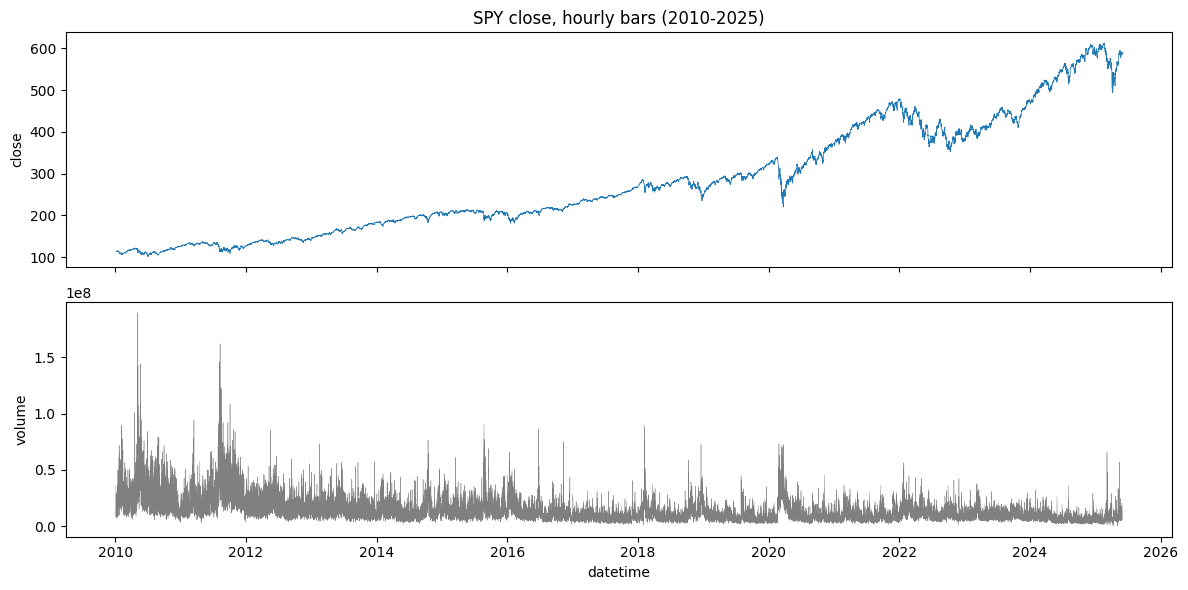

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(df["datetime"], df["close"], linewidth=0.5)
axes[0].set_ylabel("close")
axes[0].set_title("SPY close, hourly bars (2010-2025)")

axes[1].plot(df["datetime"], df["volume"], linewidth=0.3, color="gray")
axes[1].set_ylabel("volume")
axes[1].set_xlabel("datetime")

fig.tight_layout()
plt.show()

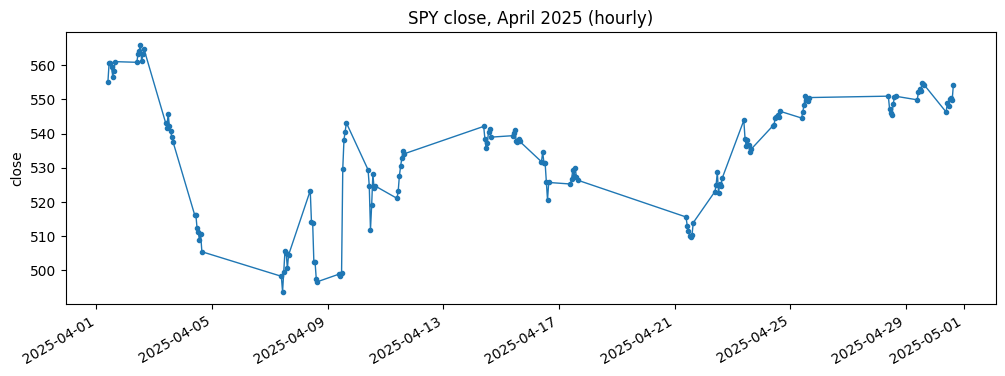

In [11]:
# Zoom in on a single recent month to sanity-check intraday shape
recent = df[(df["datetime"] >= "2025-04-01") & (df["datetime"] < "2025-05-01")]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(recent["datetime"], recent["close"], marker=".", linewidth=1)
ax.set_title("SPY close, April 2025 (hourly)")
ax.set_ylabel("close")
fig.autofmt_xdate()
plt.show()